# Microchip: process recipe in, device out

*A guided what-if over the validated chip-fabrication chain.*

You take a bare silicon wafer and **build a transistor on it** — diffuse dopant,
grow an oxide, print a gate, then read out the device. This notebook walks that
flow end to end and lets you **turn the process knobs**: diffusion time and
temperature, oxidation ambient, exposure pitch and lens, channel doping.

Every number here comes from a function **validated in isolation**
(`projects/chip/…`, each with its own test triad). The notebook is a *thin skin*
(per [ADR 0002](../../docs/decisions/0002-visualization-and-ux.md)): each compute
cell calls the headless module directly, then `ipywidgets` sliders re-run that
same code live. The figures *consume* validated arrays — they are reach, not
evidence.

The arc — the four process steps, then the device they build:

1. **Diffusion** — dopant into silicon → the **pn junction** (`diffusion_dopant`, `junction`).
2. **Oxidation** — grow SiO₂ by Deal–Grove, wet vs dry (`oxidation`).
3. **Lithography** — the aerial image, and which pitch still **resolves** (`litho`).
4. **The device** — chain all three into one MOSFET → its **threshold voltage** (`device`).

> Units are **per-module native** (the chip convention): dopant/device in
> semiconductor CGS (cm), oxide in µm, litho in nm. µm is the cross-module length
> currency.

## Setup

Imports + the inline backend. The bootstrap walks up to the repo root so
`projects.chip…` imports whether you launched Jupyter from the repo root or from
`projects/chip/`. Needs the `viz` + `notebook` extras:
`pip install -e .[viz,notebook]`.

> **The code cells are collapsed by default** so this reads as a narrative of figures and
> sliders. To see the actual `diffusion_dopant` / `oxidation` / `litho` / `device` call behind
> any output, click the **▸ arrow** (or the blue collapsed-input bar) on the left of the cell to
> expand it — every figure is just a thin call into the validated module. **Run → Run All Cells** first.

In [1]:
%matplotlib inline
import sys
from pathlib import Path

# Make `projects.chip…` importable regardless of the launch directory.
for _root in (Path.cwd(), *Path.cwd().parents):
    if (_root / "pyproject.toml").exists():
        if str(_root) not in sys.path:
            sys.path.insert(0, str(_root))
        break

import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from ipywidgets import interact

from projects.chip import diffusion_dopant as dd
from projects.chip import junction as jn
from projects.chip import oxidation as ox
from projects.chip import litho
from projects.chip import device as dev
from projects.chip import demo_device
from projects.chip.plots import junction_figure, oxidation_figure, device_figure

DOPANTS = [d for d in dd.DOPANTS if d in jn.MASETTI]   # = B / P : dopants usable end-to-end (diffusion + junction)
GATES = list(dev.GATE_POTENTIAL)    # n+poly / p+poly
print("dopants:", DOPANTS)
print("gates:  ", GATES)

dopants: ['B', 'P']
gates:   ['n+poly', 'p+poly']


## 1 — Diffusion: the pn junction

The first step writes the wafer's doping. A **two-step** diffusion does it in two
moves ([`diffusion_dopant`](diffusion_dopant.py)): a hot, short **predeposition**
holds the surface at the dopant's solid-solubility limit and lays down a thin
`erfc` layer (a fixed *dose*); then a hotter, longer **drive-in** *seals* the
surface and lets that dose redistribute deeper, the profile relaxing from `erfc`
toward a **Gaussian** and the surface concentration falling an order of magnitude.

A **pn junction** appears where the profile crosses the wafer's opposite-type
background `N_B` ([`junction`](junction.py)): the junction depth `x_j` and the
sheet resistance `R_s` are read off. Drive longer or hotter and the junction moves
**deeper** (`x_j ∝ √(D·t)`); the right panel shows that `erfc → Gaussian` morph as
the dose drives in.

<details>
<summary><b>⚛ Going deeper — the dopant atoms, and why erfc becomes Gaussian</b> &nbsp;(click to expand)</summary>

The two-step is really **one diffusion equation under two different surface boundary conditions** — the same `engines/diffusion` solver Steel froze, here in dopant *mass mode*:

- **Predeposition = a constant-source wall.** The surface is pinned at the dopant's **solid-solubility limit** `N_s` (a Dirichlet boundary set by thermodynamics, *not* a free knob — the source glass/atmosphere holds it there). Diffusion into a uniform semi-infinite solid from a fixed surface gives the **error function** `N(x) = N_s·erfc(x/2√(Dt))`, and the **dose grows** as `Q = 2·N_s·√(Dt/π)` — atoms keep arriving through the open wall.
- **Drive-in = a sealed wall.** Now the surface is closed (no-flux), so the **dose is fixed** and merely *redistributes*. A fixed dose spreading from a sealed surface relaxes toward a **Gaussian** `N(x) = (Q/√(πDt))·exp(−x²/4Dt)`: the peak **falls** while the profile **deepens** as `√(Dt)`. That falling-peak / deepening morph is exactly why the junction `x_j` (where the profile crosses `N_B`) marches deeper as you drive longer or hotter.

**The dopant field guide** — the diffusivity `D(T) = D₀·exp(−Eₐ/kT)` (cited Fair intrinsic constants) and the wafer type each species sets:

| Dopant | Type (group) | D₀, Eₐ (Fair) | Character |
|---|---|---|---|
| **B** (boron) | p-type **acceptor** (III) | 0.76 cm²/s, 3.46 eV | the demo's junction dopant; interstitial-assisted, moderate diffuser |
| **P** (phosphorus) | n-type **donor** (V) | 3.85 cm²/s, 3.66 eV | fast diffuser; home of the concentration-enhanced **kink-and-tail** |
| **Sb** (antimony) | n-type **donor** (V) | 0.214 cm²/s, 3.65 eV | slow, **vacancy**-mediated → buried layers (here for the scope-edge contrast) |

(B and P are the validated demo pair; **As** — the modern shallow-junction donor — is the widest-spread, multi-mechanism case, named as a scope edge rather than reduced to a single Arrhenius.)

**The honest scope edge.** The exact `erfc` / Gaussian forms assume a **constant** `D`. Real high-concentration diffusion is **concentration-enhanced** — `D(N)` rises with the local dopant level (charged point-defect mechanisms; the phosphorus kink-and-tail) — which the **frozen engine does not model** (its flagged-unbuilt v1.1 `D(u)` case). And a predep runs *at* the solid-solubility ceiling = the highest concentration in the whole flow = **precisely where constant-`D` is weakest**. So the exact legs are validated on their idealizations, and the realistic predep→drive-in demo's job is the **junction**, not the exact form — the same discipline Steel used to keep its analytic anchor clean.

</details>

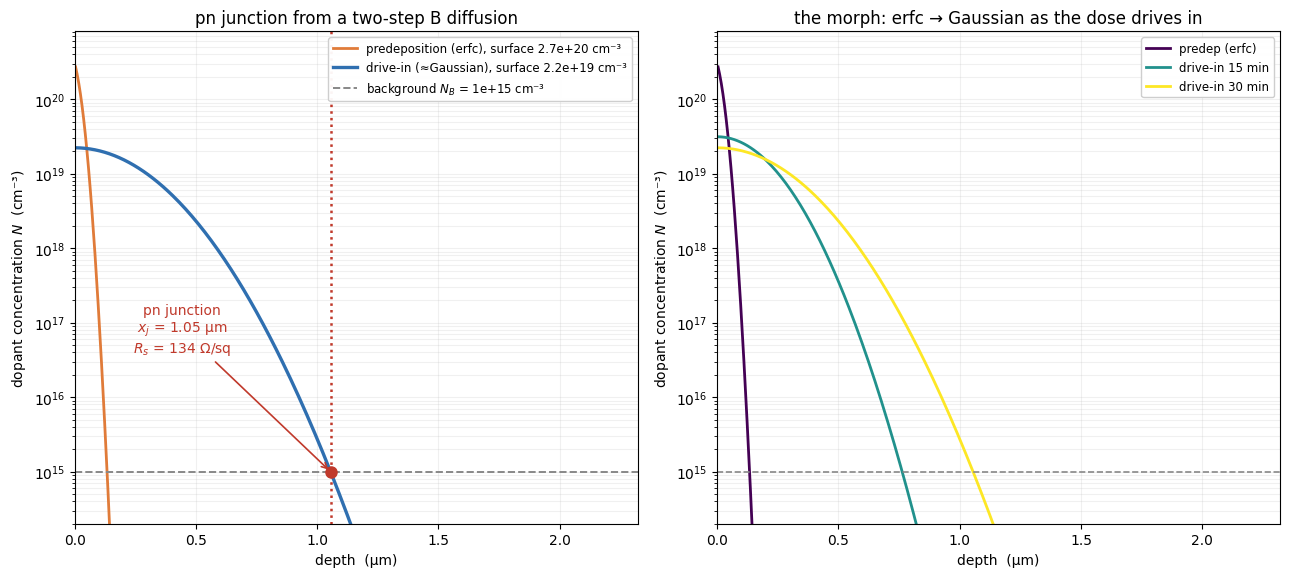

B:  x_j = 1.05 µm,   R_s = 134 Ω/sq,   surface 2.7e+20 → 2.2e+19 cm⁻³ after drive-in


In [2]:
def junction_what_if(dopant="B", T_drivein=1100.0, t_drivein_min=30.0, N_B_exp=15):
    # Recipe → junction — direct dd.two_step + jn.analyze_junction (the validated calls).
    predep, drivein = dd.two_step(dopant, T_predep=950.0, t_predep_min=15.0,
                                  T_drivein=float(T_drivein), t_drivein_min=float(t_drivein_min),
                                  length_um=4.0)
    N_B = 10.0 ** int(N_B_exp)
    j = jn.analyze_junction(drivein, dopant, N_B)
    # Morph snapshots (predep + a half-time drive-in + the full one): the erfc→Gaussian relaxation.
    _, half = dd.two_step(dopant, T_predep=950.0, t_predep_min=15.0,
                          T_drivein=float(T_drivein), t_drivein_min=float(t_drivein_min) * 0.5,
                          length_um=4.0)
    morph = [("predep (erfc)", predep.x, predep.N),
             (f"drive-in {t_drivein_min * 0.5:.0f} min", half.x, half.N),
             (f"drive-in {t_drivein_min:.0f} min", drivein.x, drivein.N)]
    xj = f"{j.x_j_um:.2f} µm" if np.isfinite(j.x_j_um) else "no junction"
    junction_figure(predep, drivein, j, morph=morph, dopant_label=dopant)
    plt.show()
    print(f"{dopant}:  x_j = {xj},   R_s = {j.R_s:.0f} Ω/sq,   surface "
          f"{predep.N[0]:.1e} → {drivein.N[0]:.1e} cm⁻³ after drive-in")

# Direct render (static, banked in the .ipynb).
junction_what_if("B", 1100.0, 30.0, 15)

In [3]:
# Live: drive the junction deeper, switch the dopant, raise the background doping.
interact(
    junction_what_if,
    dopant=widgets.Dropdown(options=DOPANTS, value="B", description="dopant"),
    T_drivein=widgets.FloatSlider(value=1100, min=900, max=1200, step=25,
                                  description="drive °C", continuous_update=True),
    t_drivein_min=widgets.FloatSlider(value=30, min=5, max=120, step=5,
                                      description="drive min", continuous_update=True),
    N_B_exp=widgets.IntSlider(value=15, min=14, max=18, description="log₁₀ N_B",
                              continuous_update=True),
);

interactive(children=(Dropdown(description='dopant', options=('B', 'P'), value='B'), FloatSlider(value=1100.0,…

## 2 — Oxidation: growing the gate oxide (Deal–Grove)

Silicon grows its own insulator: heat it in oxygen and a **SiO₂** film thickens by
the **Deal–Grove** law `x² + A·x = B(t + τ)` ([`oxidation`](oxidation.py)) — no
solver, a closed form. While thin the growth is **linear** (reaction-limited, rate
`B/A`); as the film thickens it throttles the oxidant and growth goes **parabolic**
(`√(B·t)`). The headline is the **wet-vs-dry** contrast: steam (H₂O) grows ~6×
faster than dry O₂, so dry is the controllable **gate-oxide** ambient and wet the
fast **field-oxide** one. The right panel shows *why* it bends — the growth rate
`dx/dt = B/(A + 2x)` rolling off as the oxide thickens.

<details>
<summary><b>🔥 Going deeper — the two growth regimes, and why wet beats dry</b> &nbsp;(click to expand)</summary>

Deal–Grove is a **flux balance**: oxidant from the gas dissolves into the oxide surface, **diffuses across the existing film**, then **reacts** with silicon at the buried Si/SiO₂ interface. In steady state those two fluxes are equal, and integrating gives `x² + A·x = B(t + τ)`. The single algebraic form hides **two regimes**, selected by the film thickness relative to the crossover length `A = B/(B/A)`:

| Regime | When | Rate-limited by | Law |
|---|---|---|---|
| **Linear** | thin (`x ≪ A/2`) | the **interface reaction** | `x ≈ (B/A)·t` |
| **Parabolic** | thick (`x ≫ A/2`) | **oxidant diffusion** across the grown film | `x ≈ √(B·t)` |

So `B` (the **parabolic** constant) measures how fast oxidant crosses the film, and `B/A` (the **linear** constant) how fast it reacts once it arrives. A thin film offers no diffusion resistance → growth is reaction-paced and *linear*; as the film thickens it throttles its own oxidant supply → growth slows to *parabolic*. The right-panel `dx/dt = B/(A + 2x)` is that throttling made visible.

**Why wet ≫ dry (~6×).** Steam (H₂O) is far **more soluble in SiO₂** than O₂ — roughly three orders of magnitude more oxidant dissolved at the surface — so its `B` is much larger. That is why **dry** O₂, slow and controllable, grows the thin high-quality **gate oxide**, while **wet** grows the thick **field oxide** fast. (Crystal face matters too, but only for the *reaction* step: `B/A` is ~1.68× faster on (111) than (100); `B`, a pure diffusion constant, is orientation-blind.)

**The bookkeeping and the edges.** Growing oxide **eats silicon**: `x_Si = 0.44·x_ox` (the Si→SiO₂ number-density ratio — 0.44 µm of every grown micron sits *below* the original wafer surface). Two honesty notes carried from the module: the **thin-dry (Massoud) anomaly** — Deal–Grove *under*-predicts the first ~20 nm of dry growth — is **named, not modeled** (v1 is plain Deal–Grove); and the **back-coupling** to diffusion (oxidation-enhanced diffusion + dopant **segregation** at the moving interface) is a deliberate v1 deferral — the flow here is **forward-only**.

</details>

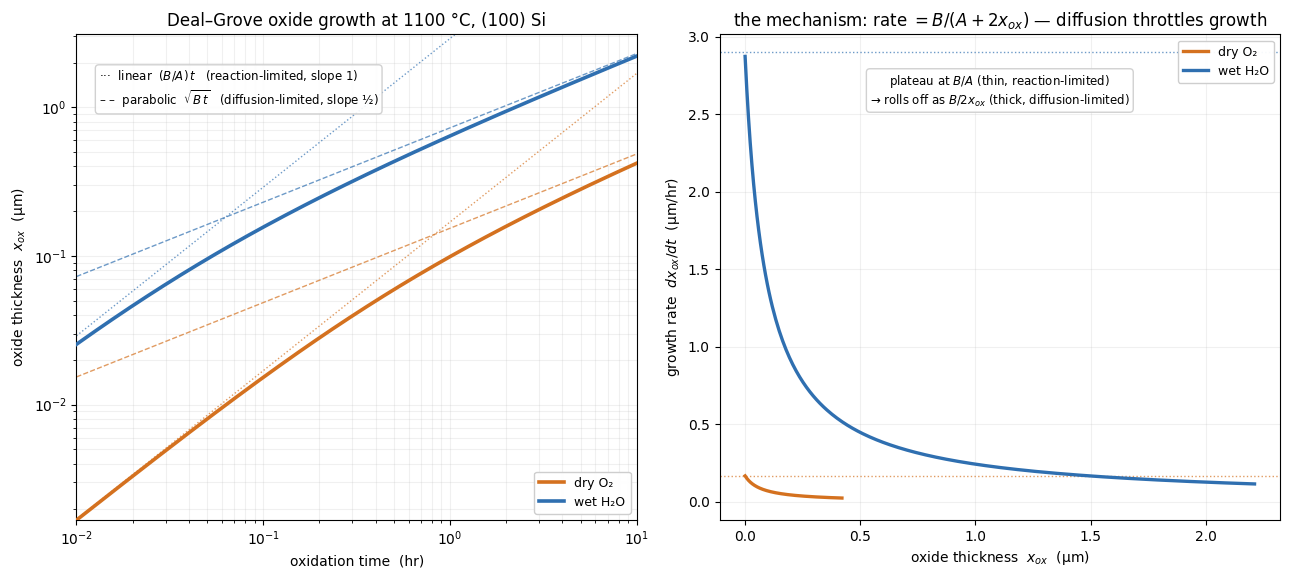

1100 °C, (100) Si, 1 h:  dry 99 nm (transition)   ·   wet 642 nm (parabolic)   ·   wet/dry = 6.5×


In [4]:
def oxide_what_if(T_celsius=1100.0, orientation="100"):
    # Wet & dry Deal–Grove curves — direct ox.oxide_rate_constants + ox.oxide_thickness.
    from projects.chip.plots import DRY_COLOR, WET_COLOR
    t_hours = np.logspace(-2.0, 1.0, 200)
    curves = []
    for ambient, label, color in (("dry", "dry O₂", DRY_COLOR), ("wet", "wet H₂O", WET_COLOR)):
        r = ox.oxide_rate_constants(ambient, float(T_celsius), orientation)
        x_ox = ox.oxide_thickness(t_hours, r.B, r.A)
        curves.append((label, x_ox, r.B, r.A, color))
    dry1 = ox.grow_oxide("dry", float(T_celsius), 60.0, orientation=orientation)
    wet1 = ox.grow_oxide("wet", float(T_celsius), 60.0, orientation=orientation)
    oxidation_figure(t_hours, curves, T_celsius=float(T_celsius), orientation=orientation)
    plt.show()
    print(f"{T_celsius:.0f} °C, ({orientation}) Si, 1 h:  dry {dry1.t_ox_nm:.0f} nm ({dry1.regime})"
          f"   ·   wet {wet1.t_ox_nm:.0f} nm ({wet1.regime})   ·   wet/dry = {wet1.t_ox / dry1.t_ox:.1f}×")

# Direct render (static, banked).
oxide_what_if(1100.0, "100")

In [5]:
# Live: heat the furnace (curves shift up) and switch the crystal face.
interact(
    oxide_what_if,
    T_celsius=widgets.FloatSlider(value=1100, min=900, max=1200, step=25,
                                  description="furnace °C", continuous_update=True),
    orientation=widgets.Dropdown(options=["100", "111"], value="100", description="Si face"),
);

interactive(children=(FloatSlider(value=1100.0, description='furnace °C', max=1200.0, min=900.0, step=25.0), D…

## 3 — Lithography: the aerial image and what resolves

The gate is *printed*: a projection lens casts the mask's pattern onto the resist
as an **aerial image** — the light intensity `I(x)` ([`litho`](litho.py)). A
line/space grating diffracts into orders, but the lens **pupil** only collects the
orders inside `|f| ≤ NA/λ`. Coarse pitches keep many orders and image crisply;
shrink the pitch and the pupil throws away the high orders, the image rounds, and
below the cutoff only the flat 0th order survives — **contrast → 0**, the pattern
stops resolving.

The left panel is the aerial image at your chosen pitch (with the resist
threshold and the printed **CD**); the right is **contrast vs pitch**, with the two
Rayleigh limits marked — `λ/NA` (`k₁=0.5`, coherent) and `λ/2NA` (`k₁=0.25`, the
two-beam floor). Partial coherence `σ` buys resolution *below* `λ/NA`.

<details>
<summary><b>💡 Going deeper — diffraction, the pupil, and why a pitch stops resolving</b> &nbsp;(click to expand)</summary>

This is **Abbe's two-step picture of imaging**. A line/space mask of pitch `p` is a grating, so it **diffracts** the illumination into discrete orders at spatial frequencies `f_m = m/p`. The projection lens has a finite aperture — the **pupil** — that collects only the orders inside the cutoff `|f| ≤ f_cut = NA/λ` and discards the rest. The image is then the **interference** of whatever orders survived. The pupil is, exactly, a **low-pass filter on spatial frequency**.

The consequence is the resolution limit, because **you need at least two orders to interfere** — one beam alone makes a flat, featureless field:

- Keep the pitch coarse → many orders pass → the image is sharp.
- Shrink the pitch → `f_m = m/p` slides outward → the lens drops the high orders → the image **rounds and loses contrast**.
- Below the cutoff only the **0th order** survives → the field goes flat → **contrast → 0**, the pattern is gone.

That cutoff *is* the **Rayleigh** rule `R = k₁·λ/NA` (`R` = resolvable half-pitch). Two limits bracket it: conventional on-axis (0th + both ±1 orders) gives `k₁ = 0.5`; pushing the illumination fully off-axis so the 0th and a single 1st order span the *whole* pupil gives the physical floor `k₁ = 0.25` — and at that pitch the pupil passes **exactly {0, +1}**, so the pure `4·cos²` two-beam fringe *falls out of the general workhorse on its own*. **Partial coherence `σ`** (= illumination NA / projection NA) is the knob in between: tilting some of the source off-axis brings in an order that on-axis would have missed, buying resolution *below* `λ/NA`.

**The method choice, and the edges.** Real sources are extended, so the workhorse is **Abbe's sum-over-source** — add the coherent sub-image from each source point *incoherently*. This is deliberately **not** the 4-D **Hopkins** transmission-cross-coefficient formulation: same physics, far higher cost — the litho **tar pit**, named in the scope ceiling. The model is honest at **low/moderate NA**: it is **scalar** (no vector / polarization), an **ideal in-focus aberration-free** pupil (no defocus, no Zernikes), and a **constant-threshold** resist (no acid diffusion / post-exposure-bake blur). All named, not papered over.

</details>

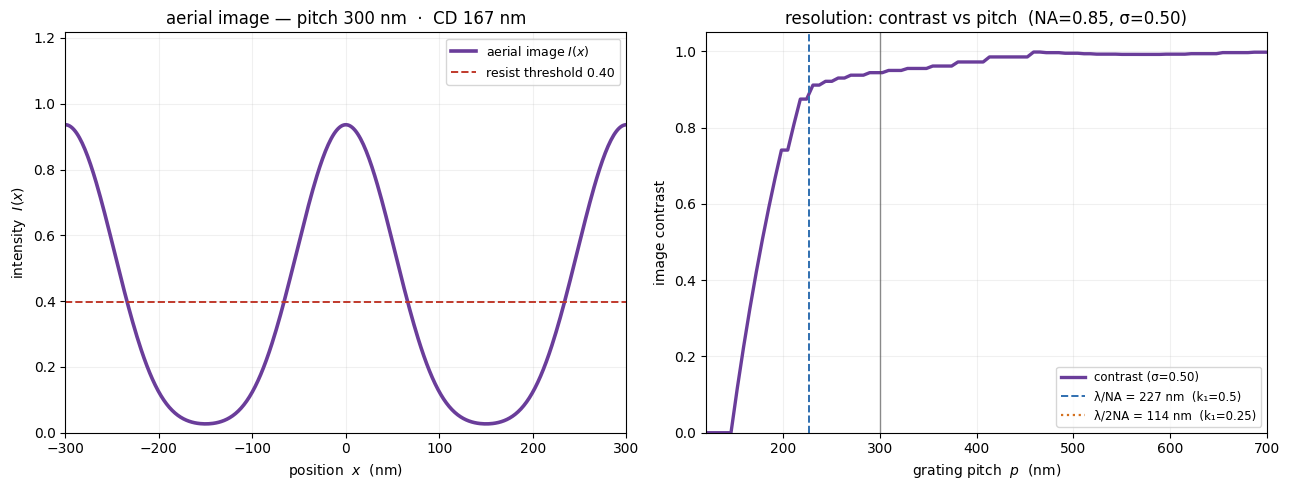

pitch 300 nm, NA 0.85, σ 0.50:  contrast 0.94   ·   NILS 4.64   ·   CD 167 nm


In [6]:
def litho_what_if(pitch_nm=300.0, NA=0.85, sigma=0.5):
    # Aerial image + contrast-vs-pitch — direct litho.abbe_image + litho.expose_grating (λ = 193 nm ArF).
    img = litho.Imaging(193.0, float(NA), float(sigma))
    x = np.linspace(-float(pitch_nm), float(pitch_nm), 400)
    I = litho.abbe_image(x, litho.grating_orders(float(pitch_nm)), img)
    threshold = float(I.mean())
    pf = litho.expose_grating(img, float(pitch_nm))
    pitches = np.linspace(120.0, 700.0, 90)
    contrasts = np.array([litho.expose_grating(img, p).contrast for p in pitches])
    cd = f"CD {pf.cd_nm:.0f} nm" if pf.resolved else "flat — unresolved"

    fig, (ax_i, ax_c) = plt.subplots(1, 2, figsize=(13, 5))
    ax_i.plot(x, I, color="#6a3d9a", lw=2.6, label="aerial image $I(x)$")
    ax_i.axhline(threshold, color="#c0392b", ls="--", lw=1.4, label=f"resist threshold {threshold:.2f}")
    ax_i.set_xlim(float(x[0]), float(x[-1])); ax_i.set_ylim(0, max(float(I.max()) * 1.3, 1e-6))
    ax_i.set_xlabel("position  $x$  (nm)"); ax_i.set_ylabel("intensity  $I(x)$")
    ax_i.set_title(f"aerial image — pitch {pitch_nm:.0f} nm  ·  {cd}")
    ax_i.legend(fontsize=9); ax_i.grid(True, alpha=0.18)

    ax_c.plot(pitches, contrasts, color="#6a3d9a", lw=2.4, label=f"contrast (σ={sigma:.2f})")
    ax_c.axvline(img.pitch_min_coherent, color="#2f6fb0", ls="--", lw=1.4,
                 label=f"λ/NA = {img.pitch_min_coherent:.0f} nm  (k₁=0.5)")
    ax_c.axvline(img.pitch_min_two_beam, color="#d4711f", ls=":", lw=1.6,
                 label=f"λ/2NA = {img.pitch_min_two_beam:.0f} nm  (k₁=0.25)")
    ax_c.axvline(float(pitch_nm), color="#444444", lw=1.0, alpha=0.6)
    ax_c.set_xlim(float(pitches[0]), float(pitches[-1])); ax_c.set_ylim(0, 1.05)
    ax_c.set_xlabel("grating pitch  $p$  (nm)"); ax_c.set_ylabel("image contrast")
    ax_c.set_title(f"resolution: contrast vs pitch  (NA={NA:.2f}, σ={sigma:.2f})")
    ax_c.legend(fontsize=8.5); ax_c.grid(True, alpha=0.18)
    plt.tight_layout(); plt.show()
    print(f"pitch {pitch_nm:.0f} nm, NA {NA:.2f}, σ {sigma:.2f}:  contrast {pf.contrast:.2f}"
          f"   ·   NILS {pf.nils:.2f}   ·   {cd}")

# Direct render (static, banked).
litho_what_if(300.0, 0.85, 0.5)

In [7]:
# Live: shrink the pitch toward the cutoff, open the aperture (NA), soften coherence (σ).
interact(
    litho_what_if,
    pitch_nm=widgets.FloatSlider(value=300, min=130, max=700, step=10,
                                 description="pitch nm", continuous_update=True),
    NA=widgets.FloatSlider(value=0.85, min=0.50, max=1.35, step=0.05,
                           description="NA", continuous_update=True),
    sigma=widgets.FloatSlider(value=0.5, min=0.1, max=0.9, step=0.1,
                              description="σ", continuous_update=True),
);

interactive(children=(FloatSlider(value=300.0, description='pitch nm', max=700.0, min=130.0, step=10.0), Float…

## 4 — The device: chaining the process into a threshold voltage

Now close the loop. Chain the three steps into **one coherent n-MOSFET** and read
the device parameter off the end ([`device`](device.py),
[`demo_device`](demo_device.py)): an n⁺ source/drain **diffused** into a p-type
channel, a thin dry **gate oxide**, a **litho**-printed gate, and the
**threshold voltage** `V_t = V_FB + 2φ_F + Q_dep/C_ox` that follows from the
channel doping `N_A` and the oxide `t_ox`. The figure below is the whole flow on
one canvas — *recipe in, V_t out* — the chip counterpart of Steel's four-curves
anchor.

<details>
<summary><b>⚡ Going deeper — the charge-sheet picture, and why short channels break it</b> &nbsp;(click to expand)</summary>

`V_t = V_FB + 2φ_F + Q_dep/C_ox` is the **charge-sheet / depletion** model, and every term is a piece of one electrostatics problem — raise the gate voltage until the surface just **inverts**:

| Term | What it is | Set by |
|---|---|---|
| `V_FB` | **flatband** voltage — the gate-to-semiconductor work-function offset | the gate material (e.g. n⁺-poly) + oxide charge |
| `2φ_F` | the **strong-inversion** condition: bend the bands until the surface electron density equals the bulk hole density (`φ_F = (kT/q)·ln(N_A/n_i)`) | channel doping `N_A` |
| `Q_dep/C_ox` | the gate voltage needed to support the **depletion charge** uncovered under the channel | `N_A` *and* the oxide `t_ox` (via `C_ox = ε_ox/t_ox`) |

The **depletion approximation** is the load-bearing idealization: at threshold the channel is a slab of fully-ionized, carrier-free acceptors, so `Q_dep = √(2·q·ε_Si·N_A·2φ_F)`. (The notebook's test *re-derives* this by integrating Poisson's equation directly — an independent anchor, not the same formula twice.) Apply a source-body reverse bias and `Q_dep` grows → the **body effect** `γ·√(2φ_F + V_SB)` lifts `V_t`. The whole thing closes by **Gauss / charge neutrality**: the gate charge balances the silicon charge, `Q_g = −(Q_dep + Q_inv)`.

**Why `V_t` here is geometry-independent — and where that ends.** Notice the formula carries **no channel length `L`**: in a *long* channel the gate alone owns the depletion charge, so `V_t` is set by the recipe (doping, oxide), not the printed dimension. That is why the litho CD here fixes the geometry (`W/L`, and so the drive current) but **not** `V_t`. Push `L` down toward the source/drain depletion widths and that stops being true: the drain and source begin to **share** the depletion charge the gate used to own (**charge sharing**), and drain bias **lowers the channel barrier** (**DIBL**) — both pull `V_t` *down* as `L` shrinks (the short-channel **roll-off**). Capturing that needs a genuinely **2-D** solution of the channel electrostatics — the meshed-TCAD wall that is this project's **named scope ceiling**. Folding CD into the long-channel `V_t` would not approximate that; it would only **destroy the exact anchor**. So v1 stops, honestly, at the long-channel compact model.

</details>

coherent n-MOSFET:  N_A = 1e+17 cm⁻³,  gate oxide 14 nm,  n+poly gate,  L = 167 nm
   V_t = V_FB(-0.97) + 2φ_F(0.83) + Q_dep/C_ox(0.68) = 0.547 V


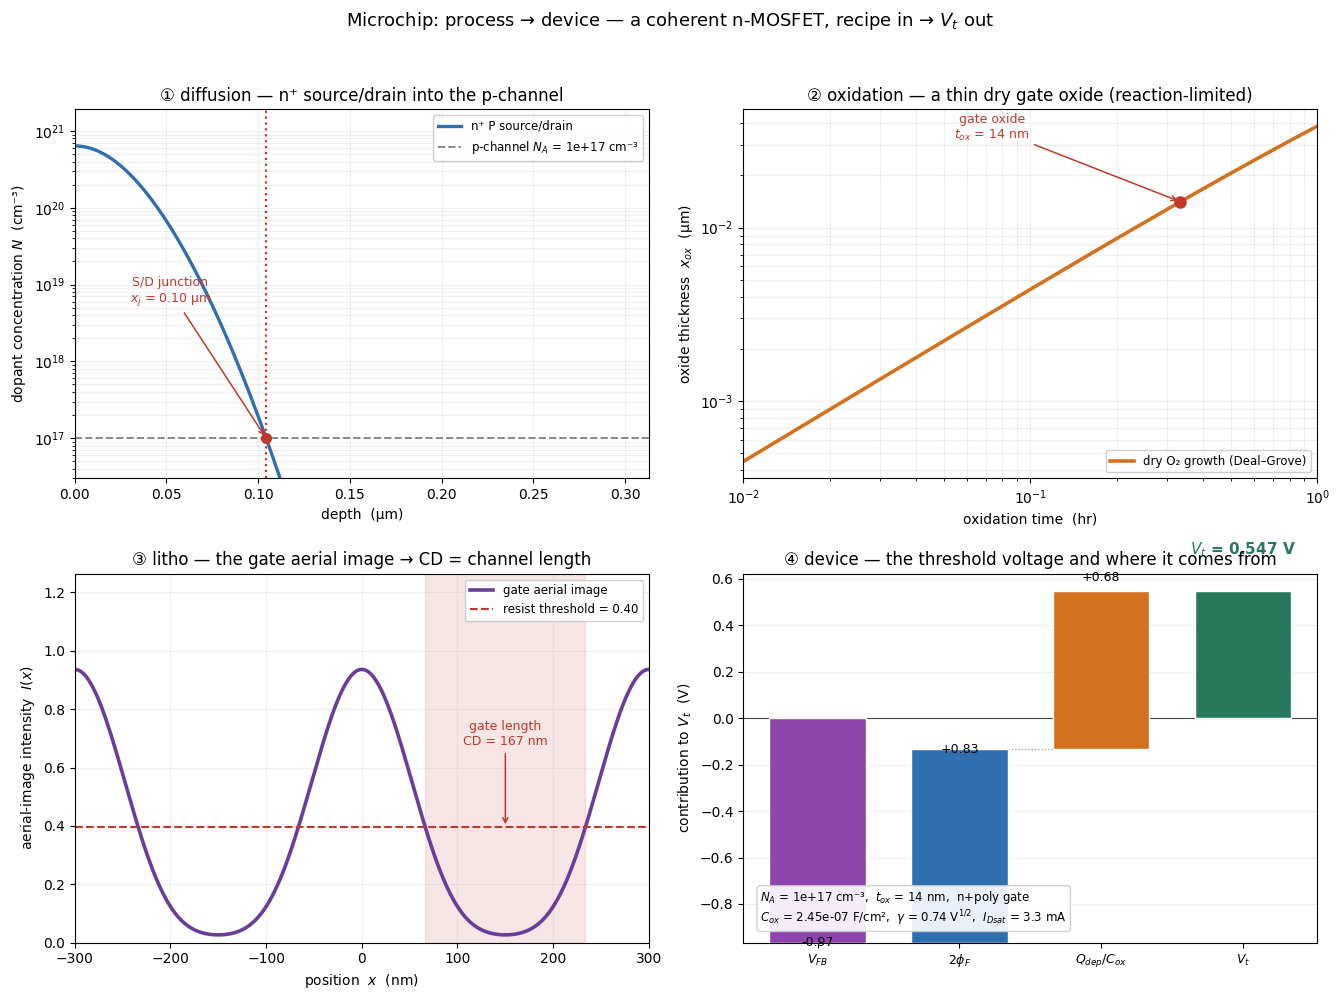

In [8]:
# The banked payoff: one coherent n-MOSFET through every process step (demo_device.compute).
r = demo_device.compute()
m = r.mos
print(f"coherent n-MOSFET:  N_A = {m.N_A:.0e} cm⁻³,  gate oxide {m.t_ox_um * 1e3:.0f} nm,  "
      f"{m.gate} gate,  L = {r.gate_feature.cd_nm:.0f} nm")
print(f"   V_t = V_FB({m.V_FB:+.2f}) + 2φ_F({m.two_phi_F:.2f}) + Q_dep/C_ox({m.body_term:.2f}) "
      f"= {m.V_t:.3f} V")
device_figure(r)
plt.show()

### Turn a process knob, watch V_t move

The payoff of the whole chain: the **gate-oxide time** (a Phase-2 process knob) and
the **channel doping** `N_A` (a Phase-1 knob) feed straight into `V_t`. A thicker
oxide weakens `C_ox` and lifts the depletion term; heavier doping raises both `2φ_F`
and `Q_dep`. The waterfall shows the three contributions stacking to the threshold.

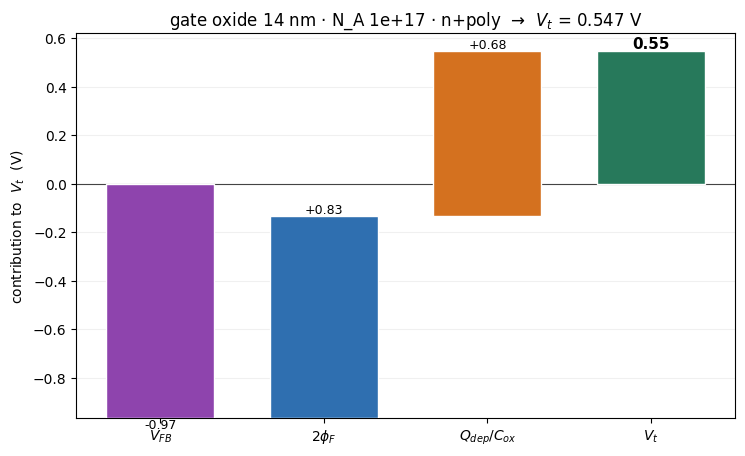

gate oxide 14 nm  ·  N_A 1e+17 cm⁻³  ·  n+poly  →  C_ox 2.45e-07 F/cm², γ 0.74 V^½,  V_t = 0.547 V


In [9]:
def vt_what_if(N_A_exp=17.0, gate_ox_min=20.0, gate="n+poly"):
    # Process knob → V_t — direct ox.grow_oxide (Phase 2) feeding dev.threshold_voltage (Phase 4).
    g = ox.grow_oxide("dry", 1000.0, float(gate_ox_min), orientation="100")
    N_A = 10.0 ** float(N_A_exp)
    m = dev.threshold_voltage(N_A, g.t_ox, gate=gate)

    runs = [(0.0, m.V_FB, "#8e44ad"),
            (m.V_FB, m.V_FB + m.two_phi_F, "#2f6fb0"),
            (m.V_FB + m.two_phi_F, m.V_t, "#d4711f")]
    fig, ax = plt.subplots(figsize=(8.5, 5))
    for i, (lo, hi, c) in enumerate(runs):
        ax.bar(i, hi - lo, bottom=lo, width=0.66, color=c, edgecolor="white", zorder=3)
        ax.text(i, hi, f"{hi - lo:+.2f}", ha="center",
                va="bottom" if hi >= lo else "top", fontsize=9)
    ax.bar(3, m.V_t, width=0.66, color="#27795b", edgecolor="white", zorder=3)
    ax.text(3, m.V_t, f"{m.V_t:.2f}", ha="center", va="bottom", fontsize=11, fontweight="bold")
    ax.axhline(0.0, color="#444444", lw=0.8)
    ax.set_xticks([0, 1, 2, 3])
    ax.set_xticklabels([r"$V_{FB}$", r"$2\phi_F$", r"$Q_{dep}/C_{ox}$", r"$V_t$"])
    ax.set_ylabel("contribution to  $V_t$  (V)")
    ax.set_title(f"gate oxide {g.t_ox_nm:.0f} nm · N_A {N_A:.0e} · {gate}  →  $V_t$ = {m.V_t:.3f} V")
    ax.grid(True, axis="y", alpha=0.18)
    plt.show()
    print(f"gate oxide {g.t_ox_nm:.0f} nm  ·  N_A {N_A:.0e} cm⁻³  ·  {gate}  →  "
          f"C_ox {m.C_ox:.2e} F/cm², γ {m.gamma:.2f} V^½,  V_t = {m.V_t:.3f} V")

# Direct render (static, banked).
vt_what_if(17.0, 20.0, "n+poly")

In [10]:
# Live: dope the channel harder, grow a thicker gate oxide, swap the gate material.
interact(
    vt_what_if,
    N_A_exp=widgets.FloatSlider(value=17.0, min=16.0, max=18.0, step=0.25,
                                description="log₁₀ N_A", continuous_update=True),
    gate_ox_min=widgets.FloatSlider(value=20.0, min=5.0, max=90.0, step=5.0,
                                    description="gate-ox min", continuous_update=True),
    gate=widgets.Dropdown(options=GATES, value="n+poly", description="gate"),
);

interactive(children=(FloatSlider(value=17.0, description='log₁₀ N_A', max=18.0, min=16.0, step=0.25), FloatSl…

## Where the numbers come from

Nothing here is fit in the notebook — every value is produced by a module
validated in isolation, each behind its own test triad (an analytical limit, a
conservation law, a published benchmark):

| Step | Module | Anchored to |
|---|---|---|
| Diffusion → junction | `diffusion_dopant`, `junction` | `erfc`/Gaussian profiles; dose conservation; Irvin `R_s·x_j`, Fair `D(T)`, Masetti `μ(N)` |
| Oxidation | `oxidation` | linear & parabolic limits; Deal–Grove rate constants (1100 °C/1 h: dry ≈ 0.10 µm, wet ≈ 0.64 µm) |
| Lithography | `litho` | two-beam `4cos²` exact; Parseval power balance; Rayleigh `k₁` (0.25 / 0.5), NILS |
| Device | `device` | independent depletion-Poisson solve; charge neutrality / Gauss; the MIT 6.012 worked example (`V_t ≈ 0.58 V`) |

The diffusion step reuses the **same frozen `engines/diffusion` solver** that
cooled Steel's Jominy bar and carburized its gear tooth — in dopant mass mode.
Per [ADR 0002](../../docs/decisions/0002-visualization-and-ux.md) the figures
above are *reach*, not evidence: the triads test the numbers, then we draw them.

Run the full validation suite for chip with `python -m tools.gate chip`, or the
demos for the publication-quality static figures
(`python -m projects.chip.demo_device`, etc.).